# VECTRI Core Equations Demo – Single Location (Explicit Formulas)

This notebook computes key VECTRI quantities for a **single grid cell** using
**explicit parameters and formulas**, without classes or helper functions.

We include:
- Parameter definitions with comments
- Core equations written directly in code cells
- A simple daily time series (180 days) for one location
- Plots of climate, hydrology, and transmission quantities


In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## 1. Parameter Definitions

We define each parameter explicitly and comment its meaning.

In [2]:
# ---------------------------
# Larval development
# ---------------------------

T_L_min = 16.0   # [°C] Minimum water temperature for larval development
K_L     = 90.9   # [degree-days] Degree-days needed to complete larval stage
T_L_max = 37.0   # [°C] Lethal upper water temperature (no larvae survive)

# Larval development equation:
# R_L = (T_wat - T_L_min) / K_L    if T_L_min < T_wat < T_L_max, else 0


In [3]:
# ---------------------------
# Larval survival
# ---------------------------

P_L_surv0  = 0.825  # Base daily larval survival (no crowding, no flushing)
M_L_max    = 300.0  # [mg m^-2] Larval biomass capacity (carrying capacity)
tau_flush  = 50.0   # [mm/day] Rainfall scale for flushing
K_flush_inf = 0.4   # Survival of early larvae under very heavy rain (asymptote)

# Total survival equation:
# P_L_surv = (1 - M_L / (w * M_L_max)) * K_flush * P_L_surv0
# with 0 <= P_L_surv <= 1


In [4]:
# ---------------------------
# Gonotrophic cycle (egg development)
# ---------------------------

T_gono_min = 7.7    # [°C] Minimum temperature for egg development
K_gono     = 37.1   # [degree-days] Degree-days needed to complete gonotrophic cycle

# Gonotrophic rate:
# R_gono = (T_eff - T_gono_min) / K_gono   if T_eff > T_gono_min, else 0
# Gonotrophic period (days) = 1 / R_gono


In [5]:
# ---------------------------
# Sporogonic (parasite) cycle
# ---------------------------

T_sporo_min = 16.0  # [°C] Minimum temperature for parasite development
K_sporo     = 111.0 # [degree-days] Degree-days for sporogonic cycle (EIP)

# Parasite development rate:
# R_sporo = (T_eff - T_sporo_min) / K_sporo   if T_eff > T_sporo_min, else 0
# EIP (days) = 1 / R_sporo


In [6]:
# ---------------------------
# Adult vector survival (Martens II)
# ---------------------------

K_mar2_0 = -4.4
K_mar2_1 =  1.31
K_mar2_2 = -0.03

# Daily survival probability:
# den = K_mar2_0 + K_mar2_1 * T_eff + K_mar2_2 * T_eff^2
# P_V_surv = exp(-1 / den)  if den > 0, else 0


In [7]:
# ---------------------------
# Indoor temperature & effective temperature
# ---------------------------

T0_indoor = 10.33  # [°C] Intercept for indoor temperature
K_indoor  = 0.58   # [-]  Slope relating outdoor T to indoor T

# Indoor temperature:
# T_indoor = T0_indoor + K_indoor * T2m
#
# Effective temperature (fraction of time indoors = beta_indoor):
# T_eff = beta_indoor * T_indoor + (1 - beta_indoor) * T2m


In [8]:
# ---------------------------
# Host–vector system
# ---------------------------

tau_zoo = 50.0   # [people/km^2 or people] Scale for zoophily/anthropophily
P_hv    = 0.2    # P(mosquito infected | bite on infectious host)
P_vh    = 0.3    # P(host infected | infectious bite)

# Mean human biting rate:
# hbr_bar = (1 - exp(-H / tau_zoo)) * V_biting / H
#
# Daily EIR:
# EIR_d = hbr_bar * CSPR
#
# Vector->host infection probability per day:
# P_v_to_h = 1 - exp(-EIR_d * P_vh)


In [9]:
# ---------------------------
# Simple pond hydrology parameters
# ---------------------------

w_max = 0.04  # Max fractional pond coverage (4% of grid cell)
E     = 5.0   # [mm/day] Evaporation
I     = 245.0 # [mm/day] Infiltration
K_w   = 0.001 # Geometry/scale factor

# Pond fraction evolution (conceptual ODE):
# dw/dt = K_w * [ rain * (w_max - w) - w * (E + I) ]


## 2. Climate Time Series (Single Location)

We create a synthetic 180-day series of daily temperature and rainfall.

In [10]:
# Time axis: 180 days
dates = pd.date_range("2025-01-01", periods=180, freq="D")
day_of_year = dates.dayofyear.values

# Synthetic air temperature [°C]: seasonal cycle around 24 °C
T2m = 24.0 + 3.0 * np.sin(2 * np.pi * (day_of_year / 365.0))

# Synthetic rainfall [mm/day]: random Gamma distribution
rng = np.random.default_rng(42)
rain = rng.gamma(shape=2.0, scale=3.0, size=len(dates))  # mean ~6 mm/day

climate_df = pd.DataFrame({"T2m": T2m, "rain": rain}, index=dates)
climate_df.head()


,T2m,rain
2025-01-01,24.051640,6.275452
2025-01-02,24.103265,8.506037
2025-01-03,24.154859,5.511647
2025-01-04,24.206407,4.935211
2025-01-05,24.257894,9.237766


## 3. Location-Specific Constants

We hold these fixed over time for this demo.

In [11]:
# Larval & hydrological state
M_L      = 3.0   # [mg m^-2] Larval biomass (assumed constant for simplicity)
L_f      = 0.25  # [-] Early larval stage (0 = very early, 1 = about to emerge)
delta_Tw = 1.5   # [°C] Water temperature offset relative to air

# Ponds: initial fraction
w0 = 0.0         # start completely dry

# Host & vector
H            = 200.0  # Humans in the cell
H_inf_frac   = 0.10   # Fraction infectious
V_biting     = 50.0   # Biting mosquitoes (number)
CSPR         = 0.10   # Circumsporozoite protein rate (infectious fraction)
beta_indoor  = 0.5    # Fraction of time mosquitoes spend indoors

H_inf = H * H_inf_frac  # number of infectious humans


## 4. Core Equations Applied Day by Day

We loop through each day and compute all quantities using the equations written explicitly.

In [12]:
n = len(climate_df)

# Hydrology
w = np.zeros(n)
w[0] = w0

# Temperatures
Twat   = np.zeros(n)
T_ind  = np.zeros(n)
T_eff  = np.zeros(n)

# Larval development & survival
R_L                = np.zeros(n)
larval_period_days = np.zeros(n)
K_flush            = np.zeros(n)
P_L_surv           = np.zeros(n)

# Adult & parasite
R_gono      = np.zeros(n)
gono_period = np.zeros(n)
R_sporo     = np.zeros(n)
EIP_days    = np.zeros(n)
P_V_surv    = np.zeros(n)

# Host-vector
hbr_bar = np.zeros(n)
EIR_d   = np.zeros(n)
P_h2v   = np.zeros(n)
P_v2h   = np.zeros(n)

for i, (date, row) in enumerate(climate_df.iterrows()):
    # --- Climate inputs ---
    T2  = row["T2m"]
    Rd  = row["rain"]

    # --- Hydrology: pond fraction ---
    if i == 0:
        w_prev = w0
    else:
        w_prev = w[i-1]
    # dw/dt = K_w * [ Rd * (w_max - w_prev) - w_prev * (E + I) ]
    dw = K_w * (Rd * (w_max - w_prev) - w_prev * (E + I))
    w[i] = w_prev + dw
    if w[i] < 0.0:
        w[i] = 0.0
    if w[i] > w_max:
        w[i] = w_max

    # --- Temperatures ---
    # Water temperature: T_wat = T2m + delta_Tw
    Tw = T2 + delta_Tw
    Twat[i] = Tw

    # Indoor temperature: T_ind = T0_indoor + K_indoor * T2m
    Ti = T0_indoor + K_indoor * T2
    T_ind[i] = Ti

    # Effective temperature: T_eff = beta_indoor*T_ind + (1 - beta_indoor)*T2m
    Teff = beta_indoor * Ti + (1.0 - beta_indoor) * T2
    T_eff[i] = Teff

    # --- Larval development ---
    # R_L = (T_wat - T_L_min) / K_L  if T_L_min < T_wat < T_L_max, else 0
    if Tw <= T_L_min or Tw >= T_L_max:
        RL = 0.0
    else:
        RL = (Tw - T_L_min) / K_L
    R_L[i] = RL
    if RL > 0.0:
        larval_period_days[i] = 1.0 / RL
    else:
        larval_period_days[i] = math.inf

    # --- Flushing factor ---
    # K_flush = L_f + (1 - L_f) * [ (1 - K_flush_inf)*exp(-Rd / tau_flush) + K_flush_inf ]
    inner = (1.0 - K_flush_inf) * math.exp(-Rd / tau_flush) + K_flush_inf
    Kf = L_f + (1.0 - L_f) * inner
    K_flush[i] = Kf

    # --- Larval survival ---
    if w[i] <= 0.0:
        P_L_surv[i] = 0.0
    else:
        # crowd_term = 1 - M_L / (w * M_L_max)
        crowd_term = 1.0 - M_L / (w[i] * M_L_max)
        if crowd_term < 0.0:
            crowd_term = 0.0
        if crowd_term > 1.0:
            crowd_term = 1.0

        PL = crowd_term * Kf * P_L_surv0
        if PL < 0.0:
            PL = 0.0
        if PL > 1.0:
            PL = 1.0
        P_L_surv[i] = PL

    # --- Gonotrophic cycle ---
    # R_gono = (T_eff - T_gono_min) / K_gono if T_eff > T_gono_min else 0
    if Teff <= T_gono_min:
        Rg = 0.0
    else:
        Rg = (Teff - T_gono_min) / K_gono
    R_gono[i] = Rg
    if Rg > 0.0:
        gono_period[i] = 1.0 / Rg
    else:
        gono_period[i] = math.inf

    # --- Sporogonic cycle ---
    # R_sporo = (T_eff - T_sporo_min) / K_sporo if T_eff > T_sporo_min else 0
    if Teff <= T_sporo_min:
        Rs = 0.0
    else:
        Rs = (Teff - T_sporo_min) / K_sporo
    R_sporo[i] = Rs
    if Rs > 0.0:
        EIP_days[i] = 1.0 / Rs
    else:
        EIP_days[i] = math.inf

    # --- Adult vector survival ---
    # den = K_mar2_0 + K_mar2_1 * T_eff + K_mar2_2 * T_eff^2
    den = K_mar2_0 + K_mar2_1 * Teff + K_mar2_2 * (Teff**2)
    if den <= 0.0:
        PV = 0.0
    else:
        PV = math.exp(-1.0 / den)
    if PV < 0.0:
        PV = 0.0
    if PV > 1.0:
        PV = 1.0
    P_V_surv[i] = PV

    # --- Host-vector ---
    # Mean human biting rate:
    # hbr_bar = (1 - exp(-H / tau_zoo)) * V_biting / H
    if H <= 0.0:
        hbr = 0.0
    else:
        phi = 1.0 - math.exp(-H / tau_zoo)
        hbr = phi * V_biting / H
    hbr_bar[i] = hbr

    # Daily EIR: EIR_d = hbr_bar * CSPR
    eir = hbr * CSPR
    EIR_d[i] = eir

    # Host -> vector infection probability per blood meal:
    # P_h2v = (H_inf / H) * P_hv
    if H <= 0.0:
        Ph2v = 0.0
    else:
        Ph2v = (H_inf / H) * P_hv
    P_h2v[i] = Ph2v

    # Vector -> host daily infection probability:
    # P_v2h = 1 - exp(-EIR_d * P_vh)
    Pv2h = 1.0 - math.exp(-eir * P_vh)
    P_v2h[i] = Pv2h


In [13]:
ts_df = pd.DataFrame(
    {
        "T2m": T2m,
        "rain": rain,
        "w": w,
        "Twat": Twat,
        "T_indoor": T_ind,
        "T_eff": T_eff,
        "R_L": R_L,
        "larval_period_days": larval_period_days,
        "K_flush": K_flush,
        "P_L_surv": P_L_surv,
        "R_gono": R_gono,
        "gono_period_days": gono_period,
        "R_sporo": R_sporo,
        "EIP_days": EIP_days,
        "P_V_surv": P_V_surv,
        "hbr": hbr_bar,
        "EIR_d": EIR_d,
        "P_h2v": P_h2v,
        "P_v2h": P_v2h,
    },
    index=dates,
)

ts_df.head()


,T2m,rain,w,Twat,T_indoor,T_eff,R_L,larval_period_days,K_flush,P_L_surv,R_gono,gono_period_days,R_sporo,EIP_days,P_V_surv,hbr,EIR_d,P_h2v,P_v2h
2025-01-01,24.051640,6.275452,0.000251,25.551640,24.279951,24.165796,0.105079,9.516690,0.946922,0.0,0.443822,2.253156,0.073566,13.593287,0.902403,0.245421,0.024542,0.02,0.007336
2025-01-02,24.103265,8.506037,0.000526,25.603265,24.309894,24.206579,0.105646,9.465531,0.929603,0.0,0.444921,2.247589,0.073933,13.525733,0.902348,0.245421,0.024542,0.02,0.007336
2025-01-03,24.154859,5.511647,0.000612,25.654859,24.339818,24.247339,0.106214,9.414948,0.953031,0.0,0.446020,2.242052,0.074300,13.458887,0.902292,0.245421,0.024542,0.02,0.007336
2025-01-04,24.206407,4.935211,0.000654,25.706407,24.369716,24.288062,0.106781,9.364948,0.957705,0.0,0.447118,2.236548,0.074667,13.392757,0.902235,0.245421,0.024542,0.02,0.007336
2025-01-05,24.257894,9.237766,0.000854,25.757894,24.399579,24.328737,0.107348,9.315534,0.924088,0.0,0.448214,2.231077,0.075034,13.327352,0.902178,0.245421,0.024542,0.02,0.007336


### 4.1 Basic summaries

In [14]:
print("=== Basic summaries over the 180 days ===")
print(f"Mean T2m           : {ts_df['T2m'].mean():.2f} °C")
print(f"Mean Twat          : {ts_df['Twat'].mean():.2f} °C")
print(f"Mean larval R_L    : {ts_df['R_L'].mean():.4f} frac/day")
print(f"Mean larval survival: {ts_df['P_L_surv'].mean():.3f}")
print(f"Mean EIP           : {ts_df['EIP_days'].replace(math.inf, float('nan')).mean():.2f} days")
print(f"Mean P_V_surv      : {ts_df['P_V_surv'].mean():.3f}")
print(f"Mean hbr           : {ts_df['hbr'].mean():.3f} bites/person/day")
print(f"Mean daily EIR     : {ts_df['EIR_d'].mean():.4f} inf. bites/person/day")
print(f"Mean P_v2h (per day): {ts_df['P_v2h'].mean():.4f}")


=== Basic summaries over the 180 days ===
Mean T2m           : 25.94 °C
Mean Twat          : 27.44 °C
Mean larval R_L    : 0.1258 frac/day
Mean larval survival: 0.000
Mean EIP           : 11.56 days
Mean P_V_surv      : 0.900
Mean hbr           : 0.245 bites/person/day
Mean daily EIR     : 0.0245 inf. bites/person/day
Mean P_v2h (per day): 0.0073


## 5. Plots

### 5.1 Air vs water temperature

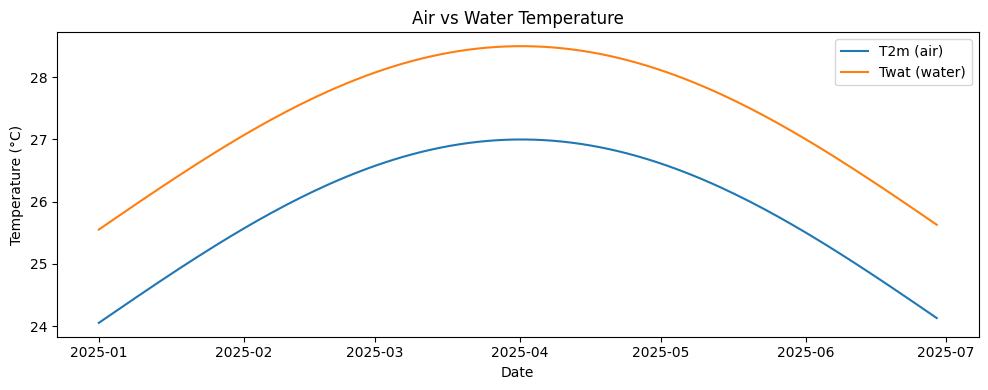

In [15]:
plt.figure(figsize=(10, 4))
plt.plot(ts_df.index, ts_df["T2m"], label="T2m (air)")
plt.plot(ts_df.index, ts_df["Twat"], label="Twat (water)")
plt.ylabel("Temperature (°C)")
plt.xlabel("Date")
plt.title("Air vs Water Temperature")
plt.legend()
plt.tight_layout()
plt.show()


### 5.2 Daily rainfall

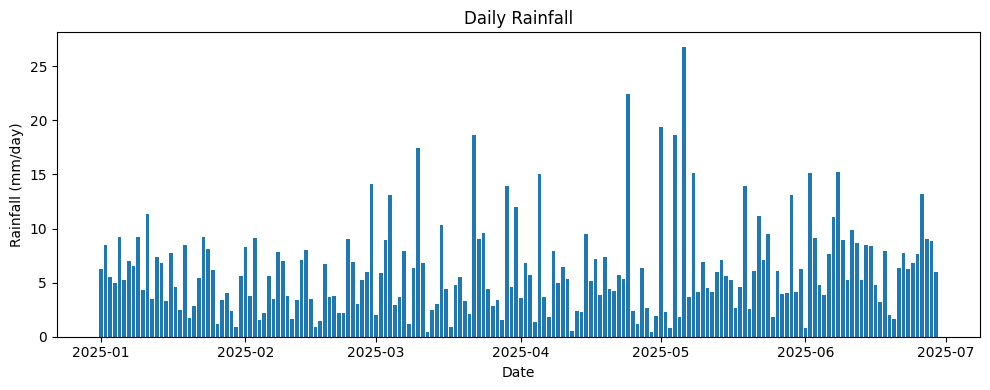

In [16]:
plt.figure(figsize=(10, 4))
plt.bar(ts_df.index, ts_df["rain"])
plt.ylabel("Rainfall (mm/day)")
plt.xlabel("Date")
plt.title("Daily Rainfall")
plt.tight_layout()
plt.show()


### 5.3 Dynamic pond coverage (w)

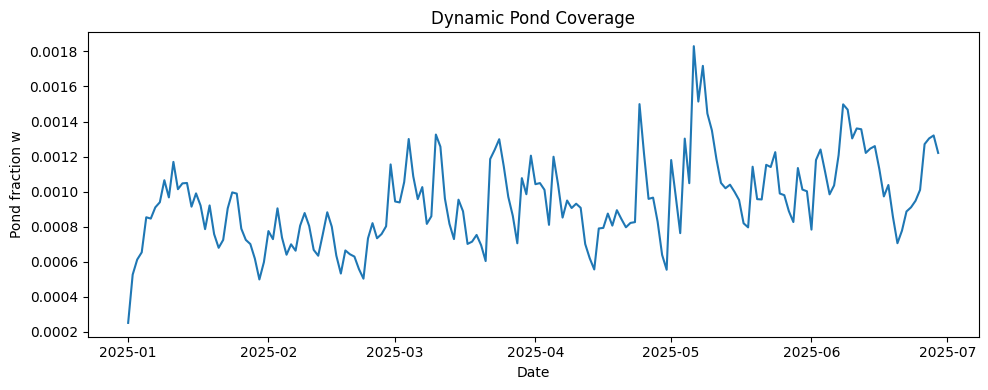

In [17]:
plt.figure(figsize=(10, 4))
plt.plot(ts_df.index, ts_df["w"])
plt.ylabel("Pond fraction w")
plt.xlabel("Date")
plt.title("Dynamic Pond Coverage")
plt.tight_layout()
plt.show()


### 5.4 Daily larval survival probability

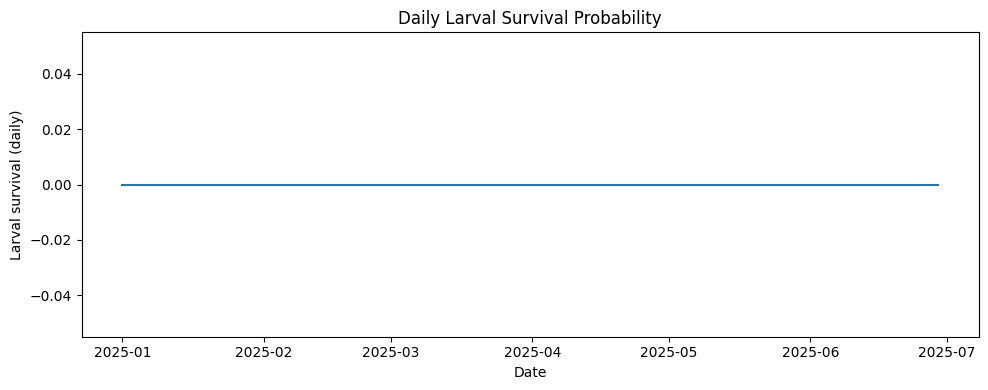

In [18]:
plt.figure(figsize=(10, 4))
plt.plot(ts_df.index, ts_df["P_L_surv"])
plt.ylabel("Larval survival (daily)")
plt.xlabel("Date")
plt.title("Daily Larval Survival Probability")
plt.tight_layout()
plt.show()


### 5.5 Gonotrophic period and EIP

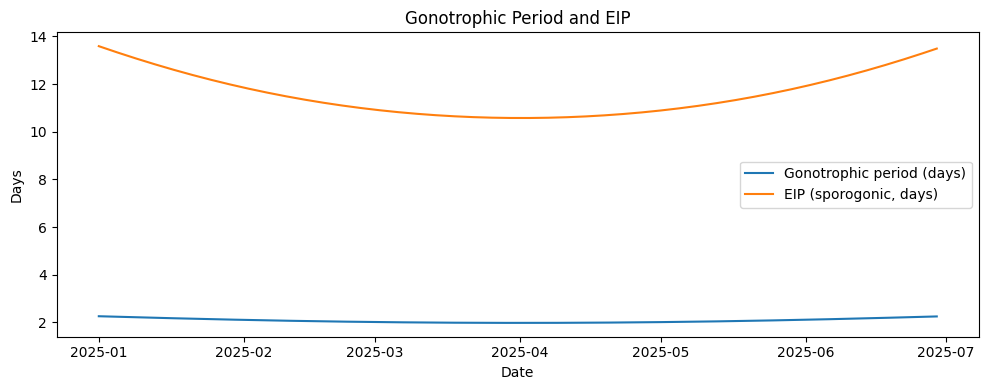

In [19]:
plt.figure(figsize=(10, 4))
plt.plot(ts_df.index, ts_df["gono_period_days"], label="Gonotrophic period (days)")
plt.plot(ts_df.index, ts_df["EIP_days"], label="EIP (sporogonic, days)")
plt.ylabel("Days")
plt.xlabel("Date")
plt.title("Gonotrophic Period and EIP")
plt.legend()
plt.tight_layout()
plt.show()


### 5.6 Daily EIR (infectious bites per person per day)

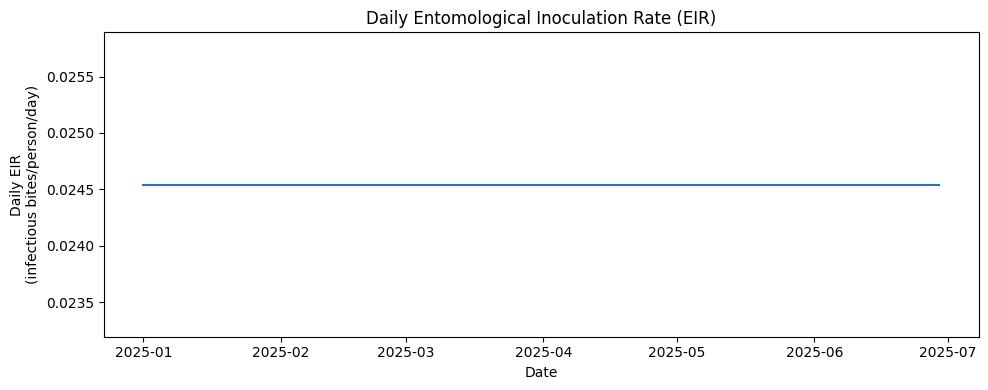

In [20]:
plt.figure(figsize=(10, 4))
plt.plot(ts_df.index, ts_df["EIR_d"])
plt.ylabel("Daily EIR\n(infectious bites/person/day)")
plt.xlabel("Date")
plt.title("Daily Entomological Inoculation Rate (EIR)")
plt.tight_layout()
plt.show()
